In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import pandas as pd
import scvi 

print("Last run with scvi-tools version:", scvi.__version__)

Last run with scvi-tools version: 1.2.2.post2


In [3]:
adata_sc_orig = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files_OLD/snRNAseq_LCNE.h5ad")
adata_sc_orig.obs['actualsex'] = adata_sc_orig.obs['sex'].str[0]  # take only first character 'M' or 'F'

In [4]:
import mygene
mg = mygene.MyGeneInfo()


In [5]:

# get chromosome info
genes = adata_sc_orig.var_names.tolist()
gene_info = mg.querymany(genes, scopes='symbol', fields='chromosome', species=1758)

gene_to_chr = {g['query']: g.get('chromosome', None) for g in gene_info if 'query' in g}
adata_sc_orig.var['chromosome'] = adata_sc_orig.var_names.map(gene_to_chr)


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
29617 input query terms found no hit:	['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587', 'Gm37323', 'Mrpl15', 'Lypla1', '


In [6]:
gene_info = mg.querymany(['Xkr4',
 'Gm1992',
 'Gm19938',
 'Gm37381',
 'Rp1',
 'Sox17',
 'Gm37587',
 'Gm37323',
 'Mrpl15',
 'Lypla1'], scopes='symbol', species='mouse',fields='all')

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
2 input query terms found dup hits:	[('Gm1992', 2), ('Gm19938', 2)]


In [7]:
gene_info

[{'query': 'Xkr4',
  'AllianceGenome': '3528744',
  'MGI': 'MGI:3528744',
  '_id': '497097',
  '_score': 14.785181,
  'accession': {'genomic': ['AC102110.8',
    'AC157542.11',
    'AC157543.8',
    'AC157545.12',
    'NC_000067.7'],
   'protein': ['AAT07099.1',
    'BAD90263.1',
    'NP_001011874.1',
    'Q5GH67.1',
    'XP_006495613.1',
    'XP_011236697.1',
    'XP_036008180.1'],
   'rna': ['AK135172.1',
    'AK220428.1',
    'AY534250.1',
    'NM_001011874.1',
    'XM_006495550.5',
    'XM_011238395.4',
    'XM_036152287.1'],
   'translation': [{'protein': 'AAT07099.1', 'rna': 'AY534250.1'},
    {'protein': 'NP_001011874.1', 'rna': 'NM_001011874.1'},
    {'protein': 'XP_011236697.1', 'rna': 'XM_011238395.4'},
    {'protein': 'XP_036008180.1', 'rna': 'XM_036152287.1'},
    {'protein': 'XP_006495613.1', 'rna': 'XM_006495550.5'},
    {'protein': 'BAD90263.1', 'rna': 'AK220428.1'}]},
  'agr': {'orthologs': [{'algorithmsmatch': '5',
     'gene_id': '497097',
     'isbestrevscore': True,

In [8]:
import re


In [9]:
mg = mygene.MyGeneInfo()
symbols = adata_sc_orig.var_names.astype(str).tolist()

def fetch_chr_mygene(symbols, chunk=1000):
    allowed = {str(i) for i in range(1,20)} | {"X","Y","MT"}
    out = {}
    for i in range(0, len(symbols), chunk):
        chunk_syms = symbols[i:i+chunk]
        hits = mg.querymany(
            chunk_syms, scopes="symbol",
            fields="genomic_pos,genomic_pos_hg19,map_location,symbol",
            species="mouse", as_dataframe=False, returnall=False, verbose=False
        )
        for h in hits:
            q = h.get("query")
            c = None
            # prefer genomic_pos.chr
            gp = h.get("genomic_pos")
            if isinstance(gp, list) and gp:
                gp = gp[0]
            if isinstance(gp, dict):
                c = gp.get("chr")
            # fallback to map_location (e.g., "XqA3" or "7")
            if c is None:
                ml = h.get("map_location")
                if isinstance(ml, str):
                    c = re.split(r"[ ;,]", ml.strip())[0]
            if isinstance(c, str):
                c = c.replace("chr","").upper()
            if c in allowed and q not in out:
                out[q] = c
    return out

gene_to_chr = fetch_chr_mygene(symbols)
adata_sc_orig.var["chromosome"] = adata_sc_orig.var_names.map(gene_to_chr).astype("category")

# filter out X/Y
mask_xy = adata_sc_orig.var["chromosome"].isin(["X","Y"])
adata_noXY = adata_sc_orig[:, ~mask_xy.fillna(False)].copy()

print(f"Mapped {adata_sc_orig.var['chromosome'].notna().sum()} / {adata_sc_orig.n_vars} genes; "
      f"removed {int(mask_xy.sum())} on X/Y.")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Mapped 27399 / 29617 genes; removed 913 on X/Y.


In [1]:
mask_xy.shape

NameError: name 'mask_xy' is not defined

In [11]:
mask_xy

Xkr4              False
Gm1992            False
Gm19938           False
Gm37381           False
Rp1               False
                  ...  
Gm10931           False
CT868723.1        False
CAAA01147332.1    False
AC163611.2        False
AC149090.1        False
Name: chromosome, Length: 29617, dtype: bool

# some sanity check 

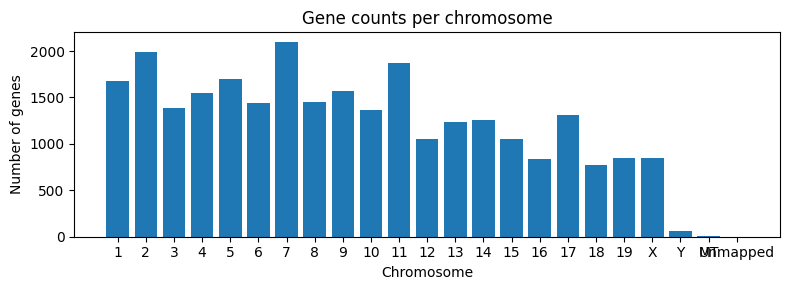

In [12]:

chrom = adata_sc_orig.var['chromosome']#.fillna('Unmapped')
order = [str(i) for i in range(1, 20)] + ['X', 'Y', 'MT', 'Unmapped']
chrom = pd.Categorical(chrom, categories=order, ordered=True)
counts = chrom.value_counts().reindex(order)

plt.figure(figsize=(8, 3))
plt.bar(counts.index, counts.values)
plt.xlabel("Chromosome")
plt.ylabel("Number of genes")
plt.title("Gene counts per chromosome")
plt.tight_layout()
plt.show()


In [13]:
# 2) How many symbols failed to map?
n_unmapped = adata_sc_orig.var['chromosome'].isna().sum()
n_unmapped, n_unmapped / adata_sc_orig.n_vars


(np.int64(2218), np.float64(0.0748894216159638))

In [14]:
# 3) Inspect a few unmapped symbols (often Gm* etc.)
adata_sc_orig.var_names[adata_sc_orig.var['chromosome'].isna()][:20].tolist()

['Gm28653',
 '4933415F23Rik',
 '4931408C20Rik',
 'Gm597',
 'Ptp4a1 ENSMUSG00000117310',
 '4931428L18Rik',
 'Gm5415',
 '2010300C02Rik',
 'Gm8251',
 'Gm553',
 'Fam126b',
 '1700122D07Rik',
 'Gpr1',
 'Gm39653',
 'March4',
 '1700027A15Rik',
 '2310015K22Rik',
 'Gm29125',
 'Gm45261',
 'Gm9747']

# are there sexually DE genes after removing the XY chromosomes? 

In [15]:
adata_noXY.shape

(4895, 28704)

In [ ]:
adata_noXY

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:453: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.ex

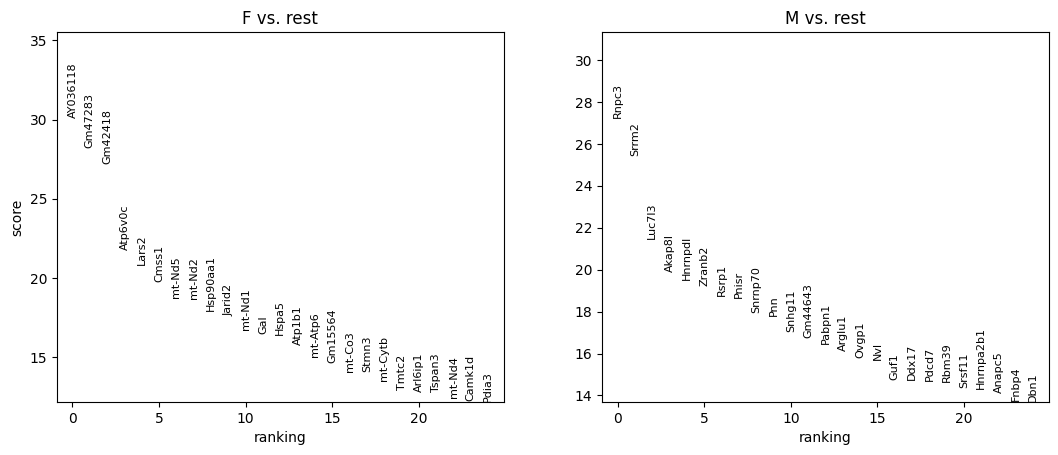

3789 sex-differential genes removed, 24915 genes remain.


In [16]:
## lognormalize otherwise get yelled at`
adata_noXY.layers["CPM"] = adata_noXY.X.copy()
sc.pp.normalize_total(adata_noXY, target_sum=1e6, layer="CPM")
adata_noXY.layers["log(CPM)"] = adata_noXY.layers["CPM"].copy()
sc.pp.log1p(adata_noXY, layer="log(CPM)")


sc.tl.rank_genes_groups(
    adata_noXY,
    groupby='actualsex',
    method='wilcoxon',  # or 't-test' or 'logreg'
)


sc.pl.rank_genes_groups(adata_noXY, n_genes=25, sharey=False)
result = adata_noXY.uns['rank_genes_groups']
pd.DataFrame({
    group: result['names'][group]
    for group in result['names'].dtype.names
}).head()


alpha = 0.05
min_lfc = 0.25  # ~log2 FC if using base-2; Scanpy uses natural log FC
df = sc.get.rank_genes_groups_df(adata_noXY, group=None)  # columns: names, scores, logfoldchanges, pvals_adj, group
sig = df[(df['pvals_adj'] < alpha) & (df['logfoldchanges'].abs() >= min_lfc)]
sex_genes = sig['names'].unique()
adata_nosex = adata_noXY[:, ~adata_noXY.var_names.isin(sex_genes)].copy()
print(len(sex_genes), "sex-differential genes removed,", adata_nosex.n_vars, "genes remain.")

# how many of these are HVGs? 

In [17]:
adata_nosex.shape, adata_noXY.shape

((4895, 24915), (4895, 28704))

In [18]:

sc.pp.highly_variable_genes(adata_noXY, n_top_genes=1500, flavor="seurat_v3",subset=False)
hvg_genes = adata_noXY.var_names[adata_noXY.var['highly_variable']].tolist()

In [19]:
len(list(sex_genes)), len(list(hvg_genes)), # 3923, 1500

(3789, 1500)

In [20]:
len(set(sex_genes).intersection(set(hvg_genes))) # thats not even so many overlaps. 

255